# TCGA Pan-Cancer EDA for Predicting TP53 Mutation Status from RNA Expression

## Objective

Explore whether **TP53 nonsynonymous mutation status** can be predicted from **TCGA RNA expression**.

This EDA is designed to support the modelling notebook by defining a clean, leakage-aware TCGA cohort and identifying the major modelling risks.

## Main EDA goals

1. Load and inspect raw TCGA/Xena RNA, mutation, and phenotype files.
2. Define a sample-level TP53 nonsynonymous mutation label.
3. Use phenotype/sample-derived patient IDs as the canonical patient identifiers.
4. Audit tumour/normal status, cancer-type composition, duplicate patients, and ambiguous TP53 annotations.
5. Define a final modelling cohort that matches the modelling notebook.
6. Check RNA missingness, dimensionality, variance structure, and broad PCA patterns.
7. Identify leakage and confounding risks before modelling.

## Key warning

In pan-cancer TCGA data, cancer type can strongly confound TP53 prediction because cancer type affects both TP53 mutation prevalence and RNA expression. Therefore, the modelling notebook should include cancer-type baselines and cancer-type-grouped evaluation.

In [1]:
import gzip
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
sns.set_context("notebook")

RANDOM_STATE = 42
TOP_VAR_GENES_FOR_PCA = 2000

## File discovery

The notebook searches common Kaggle, Colab, local, and sandbox locations for the raw TCGA/Xena files. If your files are somewhere else, add that directory to `SEARCH_ROOTS` or set the paths manually.

In [2]:
SEARCH_ROOTS = [
    Path("/kaggle/input/datasets/cameroncaputa/tp53-prediction"),
    Path("/kaggle/input/tp53-prediction"),
    Path("/kaggle/input"),
    Path("/content"),
    Path("/mnt/data"),
    Path("./data"),
    Path("."),
]


def find_first(patterns, roots=SEARCH_ROOTS, required=False):
    tried = []
    for root in roots:
        if not root.exists():
            continue
        for pattern in patterns:
            matches = [p for p in root.rglob(pattern) if p.is_file()]
            if matches:
                return sorted(matches)[0]
            tried.append(f"{root}/**/{pattern}")
    if required:
        raise FileNotFoundError("Could not find any matching file. Tried:\n" + "\n".join(tried))
    return None


RNA_PATH = find_first([
    "tcga_RSEM_gene_tpm",
    "tcga_RSEM_gene_tpm.gz",
    "*tcga_RSEM_gene_tpm*",
], required=True)

MUT_PATH = find_first([
    "mc3.v0.2.8.PUBLIC.xena",
    "mc3.v0.2.8.PUBLIC.xena.gz",
    "*mc3.v0.2.8.PUBLIC.xena*",
    "*mc3*PUBLIC*xena*",
], required=True)

PHENO_PATH = find_first([
    "Survival_SupplementalTable_S1_20171025_xena_sp",
    "Survival_SupplementalTable_S1_20171025_xena",
    "*Survival_SupplementalTable_S1_20171025*xena*",
], required=True)

TP53_TARGETS_PATH = find_first([
    "tp53_target_genes_fischer2017.csv",
    "*tp53_target_genes_fischer2017*.csv",
], required=False)

GENE_ANNOTATION_PATH = find_first([
    "*probeMap*",
    "*gene_annotation*.csv",
    "*gene_annotation*.tsv",
    "*gencode*.csv",
    "*gencode*.tsv",
], required=False)

print("RNA_PATH:", RNA_PATH)
print("MUT_PATH:", MUT_PATH)
print("PHENO_PATH:", PHENO_PATH)
print("TP53_TARGETS_PATH:", TP53_TARGETS_PATH)
print("GENE_ANNOTATION_PATH:", GENE_ANNOTATION_PATH)

RNA_PATH: data/tcga_RSEM_gene_tpm.gz
MUT_PATH: data/mc3.v0.2.8.PUBLIC.xena.gz
PHENO_PATH: data/Survival_SupplementalTable_S1_20171025_xena_sp
TP53_TARGETS_PATH: data/tp53_target_genes_fischer2017.csv
GENE_ANNOTATION_PATH: None


## Helper functions

These functions standardize TCGA sample and patient identifiers and derive tumour/normal sample type from the TCGA barcode.

In [3]:
def sniff_sep(path):
    opener = gzip.open if str(path).endswith(".gz") else open
    with opener(path, "rt", errors="ignore") as f:
        line = f.readline()
    return "	" if line.count("	") >= line.count(",") else ","


def norm_name(x):
    return re.sub(r"[^a-z0-9]+", "", str(x).lower())


def find_col(df, candidates, label, required=True):
    cols = list(df.columns)
    exact = {c.lower(): c for c in cols}
    normalized = {norm_name(c): c for c in cols}
    for cand in candidates:
        if cand.lower() in exact:
            return exact[cand.lower()]
    for cand in candidates:
        nc = norm_name(cand)
        if nc in normalized:
            return normalized[nc]
    if required:
        raise KeyError(f"Could not find {label}. Available columns: {cols}")
    return None


def looks_like_tcga_barcode(x):
    if pd.isna(x):
        return False
    return bool(re.match(r"^TCGA-[A-Za-z0-9]{2}-[A-Za-z0-9]{4}", str(x)))


def looks_like_ensembl(x):
    if pd.isna(x):
        return False
    return bool(re.match(r"^ENSG[0-9]+", str(x)))


def normalize_sample_id(x):
    """Return TCGA sample-level barcode, usually first four barcode fields."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if looks_like_tcga_barcode(s):
        parts = s.split("-")
        return "-".join(parts[:4]) if len(parts) >= 4 else s
    return s


def normalize_patient_id(x):
    """Return TCGA patient-level barcode, usually first three barcode fields."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if looks_like_tcga_barcode(s):
        parts = s.split("-")
        return "-".join(parts[:3]) if len(parts) >= 3 else s
    return s


def tcga_sample_type_code(barcode):
    """Return TCGA two-digit sample type code from the fourth barcode field."""
    if pd.isna(barcode):
        return np.nan
    s = str(barcode)
    if looks_like_tcga_barcode(s):
        parts = s.split("-")
        if len(parts) >= 4 and len(parts[3]) >= 2:
            return parts[3][:2]
    return np.nan


TCGA_SAMPLE_TYPE_MAP = {
    "01": "Primary Solid Tumor",
    "02": "Recurrent Solid Tumor",
    "03": "Primary Blood Derived Cancer - Peripheral Blood",
    "04": "Recurrent Blood Derived Cancer - Bone Marrow",
    "05": "Additional - New Primary",
    "06": "Metastatic",
    "07": "Additional Metastatic",
    "08": "Human Tumor Original Cells",
    "09": "Primary Blood Derived Cancer - Bone Marrow",
    "10": "Blood Derived Normal",
    "11": "Solid Tissue Normal",
    "12": "Buccal Cell Normal",
    "13": "EBV Immortalized Normal",
    "14": "Bone Marrow Normal",
    "20": "Control Analyte",
}

TUMOR_SAMPLE_TYPE_CODES = {"01", "02", "03", "04", "05", "06", "07", "08", "09"}

SAMPLE_PRIORITY = {
    "01": 0,  # primary solid tumour
    "03": 1,
    "06": 2,
    "02": 3,
    "05": 4,
    "07": 5,
    "08": 6,
    "09": 7,
    "04": 8,
}


def tcga_sample_type_label(barcode):
    code = tcga_sample_type_code(barcode)
    return TCGA_SAMPLE_TYPE_MAP.get(code, "Unknown") if pd.notna(code) else np.nan


def is_tcga_tumor_sample(barcode):
    code = tcga_sample_type_code(barcode)
    return code in TUMOR_SAMPLE_TYPE_CODES if pd.notna(code) else False

## Load raw files and inspect schema

In [4]:
RNA_SEP = sniff_sep(RNA_PATH)
MUT_SEP = sniff_sep(MUT_PATH)
PHENO_SEP = sniff_sep(PHENO_PATH)

# Read mutation and phenotype fully. RNA is read fully in the next section because we need expression values for EDA.
mut_raw = pd.read_csv(MUT_PATH, sep=MUT_SEP, low_memory=False, dtype=str)
pheno_raw = pd.read_csv(PHENO_PATH, sep=PHENO_SEP, low_memory=False, dtype=str)
rna_header = pd.read_csv(RNA_PATH, sep=RNA_SEP, nrows=5, low_memory=False)

print("Mutation shape:", mut_raw.shape)
print("Phenotype shape:", pheno_raw.shape)
print("RNA header preview shape:", rna_header.shape)
print("Mutation columns:", mut_raw.columns.tolist()[:30])
print("Phenotype columns:", pheno_raw.columns.tolist()[:30])
print("RNA first columns:", rna_header.columns.tolist()[:8])

display(mut_raw.head())
display(pheno_raw.head())
display(rna_header.head())

Mutation shape: (2907335, 12)
Phenotype shape: (12591, 34)
RNA header preview shape: (5, 10536)
Mutation columns: ['sample', 'chr', 'start', 'end', 'reference', 'alt', 'gene', 'effect', 'Amino_Acid_Change', 'DNA_VAF', 'SIFT', 'PolyPhen']
Phenotype columns: ['sample', '_PATIENT', 'cancer type abbreviation', 'age_at_initial_pathologic_diagnosis', 'gender', 'race', 'ajcc_pathologic_tumor_stage', 'clinical_stage', 'histological_type', 'histological_grade', 'initial_pathologic_dx_year', 'menopause_status', 'birth_days_to', 'vital_status', 'tumor_status', 'last_contact_days_to', 'death_days_to', 'cause_of_death', 'new_tumor_event_type', 'new_tumor_event_site', 'new_tumor_event_site_other', 'new_tumor_event_dx_days_to', 'treatment_outcome_first_course', 'margin_status', 'residual_tumor', 'OS', 'OS.time', 'DSS', 'DSS.time', 'DFI']
RNA first columns: ['sample', 'TCGA-19-1787-01', 'TCGA-S9-A7J2-01', 'TCGA-G3-A3CH-11', 'TCGA-EK-A2RE-01', 'TCGA-44-6778-01', 'TCGA-F4-6854-01', 'TCGA-AB-2863-03']


,sample,chr,start,end,reference,alt,gene,effect,Amino_Acid_Change,DNA_VAF,SIFT,PolyPhen
0,TCGA-02-0003-01,10,123810032,123810032,C,T,TACC2,Missense_Mutation,p.T38M,0.88,NaN,benign(0.335)
1,TCGA-02-0003-01,10,133967449,133967449,C,T,JAKMIP3,Silent,p.D723D,0.79,NaN,NaN
2,TCGA-02-0003-01,11,124489539,124489539,G,A,PANX3,Missense_Mutation,p.R296Q,0.41,tolerated(0.37),benign(0.001)
3,TCGA-02-0003-01,11,47380512,47380512,G,T,SPI1,Missense_Mutation,p.P127T,0.50,tolerated(0.08),benign(0.093)
4,TCGA-02-0003-01,11,89868837,89868837,C,T,NAALAD2,Missense_Mutation,p.R65C,0.51,deleterious(0.01),benign(0.034)


,sample,_PATIENT,cancer type abbreviation,age_at_initial_pathologic_diagnosis,gender,race,ajcc_pathologic_tumor_stage,clinical_stage,histological_type,histological_grade,initial_pathologic_dx_year,menopause_status,birth_days_to,vital_status,tumor_status,last_contact_days_to,death_days_to,cause_of_death,new_tumor_event_type,new_tumor_event_site,new_tumor_event_site_other,new_tumor_event_dx_days_to,treatment_outcome_first_course,margin_status,residual_tumor,OS,OS.time,DSS,DSS.time,DFI,DFI.time,PFI,PFI.time,Redaction
0,TCGA-OR-A5J1-01,TCGA-OR-A5J1,ACC,58,MALE,WHITE,Stage II,NaN,Adrenocortical carcinoma- Usual Type,NaN,2000,NaN,-21496,Dead,WITH TUMOR,NaN,1355,NaN,Distant Metastasis,Peritoneal Surfaces,NaN,754,Complete Remission/Response,NaN,NaN,1,1355,1,1355,1,754,1,754,NaN
1,TCGA-OR-A5J2-01,TCGA-OR-A5J2,ACC,44,FEMALE,WHITE,Stage IV,NaN,Adrenocortical carcinoma- Usual Type,NaN,2004,NaN,-16090,Dead,WITH TUMOR,NaN,1677,NaN,Distant Metastasis,Soft Tissue,NaN,289,Progressive Disease,NaN,NaN,1,1677,1,1677,NaN,NaN,1,289,NaN
2,TCGA-OR-A5J3-01,TCGA-OR-A5J3,ACC,23,FEMALE,WHITE,Stage III,NaN,Adrenocortical carcinoma- Usual Type,NaN,2008,NaN,-8624,Alive,WITH TUMOR,2091,NaN,NaN,Distant Metastasis,Lung,NaN,53,Complete Remission/Response,NaN,NaN,0,2091,0,2091,1,53,1,53,NaN
3,TCGA-OR-A5J4-01,TCGA-OR-A5J4,ACC,23,FEMALE,WHITE,Stage IV,NaN,Adrenocortical carcinoma- Usual Type,NaN,2000,NaN,-8451,Dead,WITH TUMOR,NaN,423,NaN,Locoregional Recurrence,Peritoneal Surfaces,NaN,126,Progressive Disease,NaN,NaN,1,423,1,423,NaN,NaN,1,126,NaN
4,TCGA-OR-A5J5-01,TCGA-OR-A5J5,ACC,30,MALE,WHITE,Stage III,NaN,Adrenocortical carcinoma- Usual Type,NaN,2000,NaN,-11171,Dead,WITH TUMOR,NaN,365,NaN,Locoregional Recurrence,"Other, specify",vena cava thrombus,50,Progressive Disease,NaN,NaN,1,365,1,365,NaN,NaN,1,50,NaN


,sample,TCGA-19-1787-01,TCGA-S9-A7J2-01,TCGA-G3-A3CH-11,TCGA-EK-A2RE-01,TCGA-44-6778-01,TCGA-F4-6854-01,TCGA-AB-2863-03,TCGA-C8-A1HL-01,TCGA-EW-A2FS-01,TCGA-IR-A3L7-01,TCGA-05-4420-01,TCGA-R6-A8WC-01,TCGA-DX-A3U8-01,TCGA-GL-8500-01,TCGA-E2-A153-11,TCGA-BR-A4J6-01,TCGA-EJ-7125-01,TCGA-IN-7808-01,TCGA-L5-A4OH-01,TCGA-RP-A695-06,TCGA-AX-A3G6-01,TCGA-B9-A8YH-01,TCGA-E1-A7YI-01,TCGA-PC-A5DM-01,TCGA-BR-A4QL-01,TCGA-CH-5751-01,TCGA-A2-A3XX-01,TCGA-DQ-5624-01,TCGA-KK-A7B3-01,TCGA-DQ-7591-01,TCGA-06-5412-01,TCGA-BP-4989-01,TCGA-EJ-8468-01,TCGA-CZ-5459-01,TCGA-D5-5538-01,TCGA-56-8305-01,TCGA-CZ-5468-11,TCGA-BH-A0BQ-11,TCGA-4X-A9FA-01,TCGA-DD-AAW0-01,TCGA-AA-3511-01,TCGA-Z7-A8R5-01,TCGA-CZ-4863-11,TCGA-39-5031-01,TCGA-ZG-A8QW-01,TCGA-DU-7302-01,TCGA-DJ-A3UX-01,TCGA-ZN-A9VQ-01,TCGA-EI-6512-01,TCGA-J4-A83K-01,TCGA-EE-A17X-06,TCGA-HZ-7922-01,TCGA-DD-AACA-02,TCGA-DD-AACA-01,TCGA-D3-A8GD-06,TCGA-13-1485-01,TCGA-QG-A5YX-01,TCGA-ZG-A9MC-01,TCGA-DU-A7TI-01,TCGA-A3-3335-01,TCGA-BR-8372-01,TCGA-HC-7742-01,TCGA-DD-A3A6-11,TCGA-64-1679-01,TCGA-CV-5976-01,TCGA-25-1315-01,TCGA-2G-AAFZ-01,TCGA-LN-A4MQ-01,TCGA-CV-6948-01,TCGA-K7-AAU7-01,TCGA-CJ-6028-01,TCGA-B6-A0RL-01,TCGA-CZ-5456-01,TCGA-EL-A3D0-01,TCGA-EM-A22Q-01,TCGA-49-6744-01,TCGA-L5-A4ON-01,TCGA-FS-A1ZF-06,TCGA-ZN-A9VU-01,TCGA-Q3-A5QY-01,TCGA-AJ-A3BI-01,TCGA-W2-A7UY-01,TCGA-BH-A204-11,TCGA-E3-A3E2-01,TCGA-FB-A545-01,TCGA-44-2657-11,TCGA-G4-6320-01,TCGA-EB-A41A-01,TCGA-55-6982-01,TCGA-RC-A7SH-01,TCGA-CC-A3MA-01,TCGA-DD-A3A5-11,TCGA-RC-A7SB-01,TCGA-CM-6164-01,TCGA-ET-A3BW-01,TCGA-09-0369-01,TCGA-E2-A2P6-01,TCGA-VD-A8KF-01,TCGA-EL-A4JZ-01,...,TCGA-AB-2833-03,TCGA-EE-A2MF-06,TCGA-D8-A1XR-01,TCGA-50-5072-01,TCGA-AB-2964-03,TCGA-HI-7171-01,TCGA-AR-A0TQ-01,TCGA-G3-A3CG-01,TCGA-BB-7863-01,TCGA-DU-6406-01,TCGA-BR-4255-01,TCGA-AA-3675-01,TCGA-JV-A75J-01,TCGA-DD-A1ED-01,TCGA-BH-A18P-01,TCGA-VD-A8KJ-01,TCGA-A6-6782-01,TCGA-BR-A4CR-01,TCGA-2Y-A9H8-01,TCGA-61-1721-01,TCGA-56-8628-01,TCGA-2Y-A9GT-01,TCGA-EO-A3AZ-01,TCGA-3N-A9WD-06,TCGA-29-1784-01,TCGA-2L-AAQI-01,TCGA-HS-A5N9-01,TCGA-VS-A9UT-01,TCGA-E2-A15O-01,TCGA-50-5045-01,TCGA-DA-A95W-06,TCGA-BP-4332-01,TCGA-AO-A12C-01,TCGA-86-8674-01,TCGA-CZ-5451-11,TCGA-FF-8043-01,TCGA-P3-A5Q5-01,TCGA-N8-A4PQ-01,TCGA-50-8457-01,TCGA-ZJ-AAX8-01,TCGA-OL-A97C-01,TCGA-18-3416-01,TCGA-B8-4146-01,TCGA-AB-2937-03,TCGA-56-7222-11,TCGA-68-7755-01,TCGA-EE-A2GN-06,TCGA-V1-A9ZR-01,TCGA-2J-AABK-01,TCGA-EJ-A6RC-01,TCGA-EL-A3GP-01,TCGA-D9-A4Z6-06,TCGA-E2-A15K-11,TCGA-06-0743-01,TCGA-H2-A3RI-01,TCGA-21-5787-01,TCGA-BJ-A18Z-01,TCGA-D7-A6EX-01,TCGA-TM-A84B-01,TCGA-OR-A5K0-01,TCGA-FY-A4B4-01,TCGA-BH-A18G-01,TCGA-13-0725-01,TCGA-B6-A0IA-01,TCGA-A8-A090-01,TCGA-BB-4217-01,TCGA-5T-A9QA-01,TCGA-TN-A7HJ-01,TCGA-AN-A0XT-01,TCGA-TS-A8AS-01,TCGA-J4-8198-01,TCGA-DU-A76O-01,TCGA-EE-A29L-06,TCGA-4X-A9F9-01,TCGA-C5-A1BJ-01,TCGA-G2-AA3C-01,TCGA-HU-8602-01,TCGA-CR-6470-01,TCGA-CH-5768-01,TCGA-2H-A9GM-01,TCGA-XH-A853-01,TCGA-CM-4751-01,TCGA-AO-A0J4-01,TCGA-55-6985-11,TCGA-YL-A9WK-01,TCGA-77-6844-01,TCGA-IN-AB1X-11,TCGA-A2-A0YK-01,TCGA-18-3414-01,TCGA-13-1481-01,TCGA-DJ-A2QC-01,TCGA-A8-A09K-01,TCGA-61-1907-01,TCGA-IB-7885-01,TCGA-95-7947-01,TCGA-VQ-AA6F-01,TCGA-BR-8588-01,TCGA-24-2254-01,TCGA-DD-A115-01,TCGA-FV-A3I0-11
0,ENSG00000242268.2,-9.9658,0.2998,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-0.6873,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-0.8599,-0.4521,-9.9658,-9.9658,-9.9658,-4.6082,-9.9658,-9.9658,-9.9658,-4.2934,-3.6259,-9.9658,-4.6082,-9.9658,-9.9658,-9.9658,-9.9658,-4.6082,-9.9658,-4.6082,-9.9658,-9.9658,-9.9658,-9.9658,-2.5479,-1.2481,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.965800,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-0.6193,-1.3921,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-2.0529,-9.9658,-9.9658,-3.1714,-3.3076,-9.9658,-5.0116,1.0711,-2.1140,-9.9658,-9.9658,-9.9658,-9.9658,-4.6082,-9.9658,-9.9658,-0.9686,0.1257,-3.4580,-4.2934,-9.9658,-9.9658,-9.9658,-4.6082,-9.9658,-9.9658,-9.9658,-9.9658,-0.4131,-9.9658,-9.9658,-9.9658,-

In [5]:
MUT_SAMPLE_COL = find_col(
    mut_raw,
    ["Tumor_Sample_Barcode", "sample", "sample_id", "SampleID", "ModelID"],
    "mutation sample column",
)
MUT_GENE_COL = find_col(
    mut_raw,
    ["Hugo_Symbol", "HugoSymbol", "gene", "Gene", "symbol"],
    "mutation gene column",
)
MUT_EFFECT_COLS = [
    c for c in [
        find_col(mut_raw, ["Variant_Classification"], "Variant_Classification", required=False),
        find_col(mut_raw, ["VariantInfo"], "VariantInfo", required=False),
        find_col(mut_raw, ["effect"], "effect", required=False),
        find_col(mut_raw, ["Variant_Type"], "Variant_Type", required=False),
        find_col(mut_raw, ["VariantType"], "VariantType", required=False),
        find_col(mut_raw, ["Protein_Change"], "Protein_Change", required=False),
        find_col(mut_raw, ["ProteinChange"], "ProteinChange", required=False),
        find_col(mut_raw, ["Amino_Acid_Change"], "Amino_Acid_Change", required=False),
        find_col(mut_raw, ["Consequence"], "Consequence", required=False),
    ] if c is not None
]
assert len(MUT_EFFECT_COLS) > 0, "Could not find any mutation effect / classification columns."

PHENO_SAMPLE_COL = find_col(
    pheno_raw,
    ["sample", "sample_id", "SampleID", "submitter_id", "Tumor_Sample_Barcode", "ModelID"],
    "phenotype sample column",
)
PHENO_PATIENT_COL = find_col(
    pheno_raw,
    ["_PATIENT", "patient", "patient_id", "PatientID", "case_submitter_id", "participant_id"],
    "phenotype patient column",
    required=False,
)
CANCER_TYPE_COL = find_col(
    pheno_raw,
    ["cancer type abbreviation", "cancer_type_abbreviation", "acronym", "project_id", "OncotreeCode", "primary_disease"],
    "cancer type column",
)

print("Chosen mutation sample column:", MUT_SAMPLE_COL)
print("Chosen mutation gene column:", MUT_GENE_COL)
print("Chosen mutation effect columns:", MUT_EFFECT_COLS)
print("Chosen phenotype sample column:", PHENO_SAMPLE_COL)
print("Chosen phenotype patient column:", PHENO_PATIENT_COL)
print("Chosen cancer type column:", CANCER_TYPE_COL)

Chosen mutation sample column: sample
Chosen mutation gene column: gene
Chosen mutation effect columns: ['effect', 'Amino_Acid_Change']
Chosen phenotype sample column: sample
Chosen phenotype patient column: _PATIENT
Chosen cancer type column: cancer type abbreviation


## Identifier and schema decisions

- RNA matrix orientation is inferred from the header.
- Mutation and phenotype identifiers are standardized to sample-level TCGA barcodes.
- Patient ID should come from the phenotype table when available, falling back to the sample barcode.
- TP53 mutation-derived patient IDs are **not** allowed to overwrite patient IDs for mutation-negative samples.
- Tumour/normal status is derived from the TCGA sample-type code in the fourth barcode field.

## Load RNA expression matrix

The expected Xena RNA layout is usually genes as rows and samples as columns. The code below detects that layout and converts the matrix to samples × genes.

In [6]:
def infer_rna_orientation(header_df):
    cols = list(header_df.columns)
    first_col = cols[0]
    other_cols = cols[1:min(len(cols), 200)]

    first_norm = norm_name(first_col)
    sample_named_first = first_norm in {"sample", "sampleid", "samplebarcode", "submitterid", "modelid"}
    tcga_header_frac = np.mean([looks_like_tcga_barcode(c) for c in other_cols]) if other_cols else 0.0
    ensembl_header_frac = np.mean([looks_like_ensembl(c) for c in other_cols]) if other_cols else 0.0

    if sample_named_first and ensembl_header_frac >= 0.05:
        return "sample_x_gene"
    if tcga_header_frac >= 0.20:
        return "gene_x_sample"
    if sample_named_first:
        return "sample_x_gene"

    preview_first_values = header_df.iloc[:, 0].astype(str).tolist()
    preview_tcga_frac = np.mean([looks_like_tcga_barcode(v) for v in preview_first_values]) if preview_first_values else 0.0
    if preview_tcga_frac >= 0.5 and ensembl_header_frac >= 0.02:
        return "sample_x_gene"

    return "gene_x_sample"


RNA_ORIENTATION = infer_rna_orientation(rna_header)
RNA_FIRST_COL = rna_header.columns[0]

print("Inferred RNA orientation:", RNA_ORIENTATION)
print("RNA first column:", RNA_FIRST_COL)

rna_raw = pd.read_csv(RNA_PATH, sep=RNA_SEP, low_memory=False)

if RNA_ORIENTATION == "gene_x_sample":
    gene_col = rna_raw.columns[0]
    rna_mat = rna_raw.set_index(gene_col).T
    rna_mat.index = rna_mat.index.map(normalize_sample_id)
    rna_mat.index.name = "sample_id"
    rna_mat.columns = rna_mat.columns.astype(str)
else:
    sample_col = rna_raw.columns[0]
    rna_mat = rna_raw.copy()
    rna_mat[sample_col] = rna_mat[sample_col].map(normalize_sample_id)
    rna_mat = rna_mat.set_index(sample_col)
    rna_mat.index.name = "sample_id"
    rna_mat.columns = rna_mat.columns.astype(str)

n_duplicate_rna_samples = int(rna_mat.index.duplicated().sum())
if n_duplicate_rna_samples > 0:
    print(f"Warning: {n_duplicate_rna_samples} duplicate normalized RNA sample IDs. Keeping first occurrence for EDA.")
    rna_mat = rna_mat.loc[~rna_mat.index.duplicated(keep="first")].copy()

# Convert expression values to numeric. Xena TPM matrices are typically already log-scale numeric values.
rna_mat = rna_mat.apply(pd.to_numeric, errors="coerce")

print("RNA matrix shape, samples x genes:", rna_mat.shape)
print("Unique RNA samples:", rna_mat.index.nunique())
print("Duplicated RNA samples after cleanup:", int(rna_mat.index.duplicated().sum()))
print("RNA missing-value fraction:", float(rna_mat.isna().mean().mean()))
display(rna_mat.iloc[:3, :5])

Inferred RNA orientation: gene_x_sample
RNA first column: sample
RNA matrix shape, samples x genes: (10535, 60498)
Unique RNA samples: 10535
Duplicated RNA samples after cleanup: 0
RNA missing-value fraction: 0.0


sample,ENSG00000242268.2,ENSG00000259041.1,ENSG00000270112.3,ENSG00000167578.16,ENSG00000278814.1
sample_id,,,,,
TCGA-19-1787-01,-9.9658,-9.9658,-3.8160,5.2998,-9.9658
TCGA-S9-A7J2-01,0.2998,-9.9658,-3.0469,4.8881,-9.9658
TCGA-G3-A3CH-11,-9.9658,-9.9658,-9.9658,3.5572,-9.9658


,value
n_samples,10535.0
n_genes,60498.0
overall_missing_fraction,0.0
max_sample_missing_fraction,0.0
max_gene_missing_fraction,0.0
duplicated_gene_ids,0.0


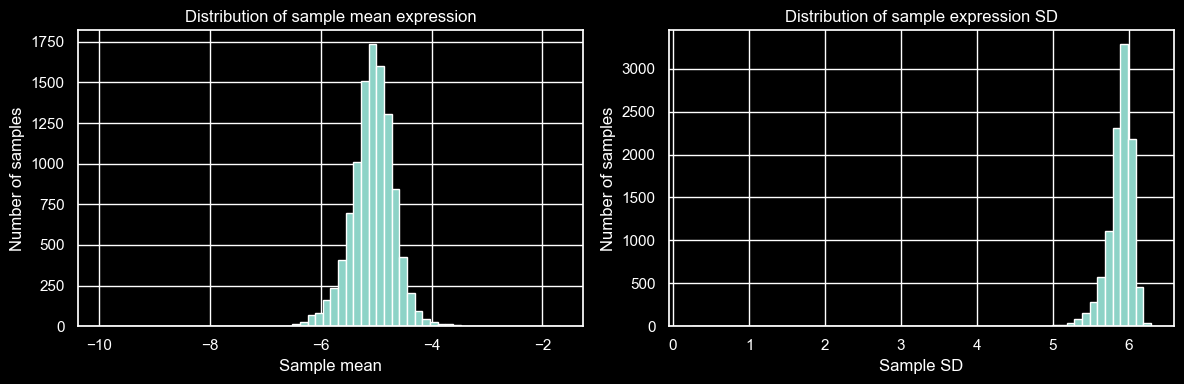

In [7]:
# Basic RNA QC at the matrix level.
sample_missing = rna_mat.isna().mean(axis=1)
gene_missing = rna_mat.isna().mean(axis=0)
sample_means = rna_mat.mean(axis=1)
sample_stds = rna_mat.std(axis=1)

rna_qc_summary = pd.Series({
    "n_samples": rna_mat.shape[0],
    "n_genes": rna_mat.shape[1],
    "overall_missing_fraction": float(rna_mat.isna().mean().mean()),
    "max_sample_missing_fraction": float(sample_missing.max()),
    "max_gene_missing_fraction": float(gene_missing.max()),
    "duplicated_gene_ids": int(pd.Index(rna_mat.columns).duplicated().sum()),
})

display(rna_qc_summary.to_frame("value"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(sample_means, bins=60)
axes[0].set_title("Distribution of sample mean expression")
axes[0].set_xlabel("Sample mean")
axes[0].set_ylabel("Number of samples")

axes[1].hist(sample_stds, bins=60)
axes[1].set_title("Distribution of sample expression SD")
axes[1].set_xlabel("Sample SD")
axes[1].set_ylabel("Number of samples")
plt.tight_layout()
plt.show()

## TP53 mutation label construction

The primary label is `TP53_mut_nonsyn`: whether a sample has at least one nonsynonymous / protein-altering TP53 mutation.

This is preferred over using any TP53 row because synonymous and ambiguous TP53 annotations should not be treated as equivalent to protein-altering TP53 mutations.

In [8]:
tp53_rows = mut_raw.loc[mut_raw[MUT_GENE_COL].astype(str).str.upper().eq("TP53")].copy()
tp53_rows["sample_id"] = tp53_rows[MUT_SAMPLE_COL].map(normalize_sample_id)
tp53_rows["patient_id"] = tp53_rows[MUT_SAMPLE_COL].map(normalize_patient_id)

tp53_rows["effect_text"] = (
    tp53_rows[MUT_EFFECT_COLS]
    .fillna("")
    .astype(str)
    .agg(" | ".join, axis=1)
    .str.strip()
)

PROTEIN_ALTERING_KEYWORDS = {
    "missense", "nonsense", "frame_shift", "frameshift", "splice", "stop_gained",
    "stoplost", "stop_lost", "nonstop", "translation_start", "start_codon",
    "inframe", "in_frame", "trunc", "deleterious", "nonsynonymous", "non_synonymous"
}
SYNONYMOUS_KEYWORDS = {"silent", "synonymous"}


def classify_tp53_effect(effect):
    if pd.isna(effect):
        return "unknown"
    e = str(effect).strip().lower()
    if e == "":
        return "unknown"
    if any(k in e for k in SYNONYMOUS_KEYWORDS):
        return "synonymous"
    if "missense" in e:
        return "missense"
    if any(k in e for k in ["nonsense", "stop_gained", "nonstop", "frame_shift", "frameshift", "trunc"]):
        return "truncating"
    if "splice" in e:
        return "splice"
    if "inframe" in e or "in_frame" in e:
        return "inframe"
    if any(k in e for k in PROTEIN_ALTERING_KEYWORDS):
        return "protein_altering"
    return "other_or_unknown"


tp53_rows["tp53_event_class"] = tp53_rows["effect_text"].map(classify_tp53_effect)
tp53_rows["is_tp53_nonsyn"] = tp53_rows["tp53_event_class"].isin(
    ["missense", "truncating", "splice", "inframe", "protein_altering"]
)
tp53_rows["is_tp53_ambiguous"] = tp53_rows["tp53_event_class"].isin(["unknown", "other_or_unknown"])

print("TP53 mutation rows:", len(tp53_rows))
display(tp53_rows[[MUT_SAMPLE_COL, "sample_id", "patient_id", "effect_text", "tp53_event_class"]].head())
display(tp53_rows["tp53_event_class"].value_counts(dropna=False).to_frame("n_rows"))

TP53 mutation rows: 3729


,sample,sample_id,patient_id,effect_text,tp53_event_class
19,TCGA-02-0003-01,TCGA-02-0003-01,TCGA-02-0003,Missense_Mutation | p.R282W,missense
20,TCGA-02-0003-01,TCGA-02-0003-01,TCGA-02-0003,Missense_Mutation | p.H178Q,missense
80,TCGA-02-0033-01,TCGA-02-0033-01,TCGA-02-0033,Missense_Mutation | p.R248Q,missense
211,TCGA-02-0055-01,TCGA-02-0055-01,TCGA-02-0055,Missense_Mutation | p.V216M,missense
363,TCGA-02-2483-01,TCGA-02-2483-01,TCGA-02-2483,Missense_Mutation | p.R273H,missense


,n_rows
tp53_event_class,
missense,2382
truncating,921
splice,238
synonymous,90
inframe,79
other_or_unknown,18
protein_altering,1


In [9]:
tp53_sample = (
    tp53_rows.groupby("sample_id", dropna=True)
    .agg(
        patient_id=("patient_id", "first"),
        n_tp53_rows=("sample_id", "size"),
        has_any_tp53_row=("sample_id", lambda x: True),
        has_any_tp53_nonsyn=("is_tp53_nonsyn", "max"),
        has_any_tp53_ambiguous=("is_tp53_ambiguous", "max"),
        n_unique_tp53_event_classes=("tp53_event_class", "nunique"),
        example_effects=("effect_text", lambda x: "; ".join(pd.Series(x).dropna().astype(str).unique()[:5])),
    )
    .reset_index()
)

tp53_sample["TP53_mut_nonsyn"] = tp53_sample["has_any_tp53_nonsyn"].astype(int)
tp53_sample["TP53_mut_ambiguous"] = tp53_sample["has_any_tp53_ambiguous"].astype(int)
tp53_sample["has_mixed_tp53_annotation"] = (
    tp53_sample["has_any_tp53_nonsyn"] & tp53_sample["has_any_tp53_ambiguous"]
).astype(int)

print("Samples with any TP53 mutation row:", len(tp53_sample))
display(tp53_sample.head())
display(tp53_sample[["TP53_mut_nonsyn", "TP53_mut_ambiguous", "has_mixed_tp53_annotation"]].sum().to_frame("n_samples"))
display(tp53_sample[["TP53_mut_nonsyn", "TP53_mut_ambiguous", "has_mixed_tp53_annotation"]].mean().to_frame("fraction_among_tp53_row_samples"))

Samples with any TP53 mutation row: 3325


,sample_id,patient_id,n_tp53_rows,has_any_tp53_row,has_any_tp53_nonsyn,has_any_tp53_ambiguous,n_unique_tp53_event_classes,example_effects,TP53_mut_nonsyn,TP53_mut_ambiguous,has_mixed_tp53_annotation
0,TCGA-02-0003-01,TCGA-02-0003,2,True,True,False,1,Missense_Mutation | p.R282W; Missense_Mutation...,1,0,0
1,TCGA-02-0033-01,TCGA-02-0033,1,True,True,False,1,Missense_Mutation | p.R248Q,1,0,0
2,TCGA-02-0055-01,TCGA-02-0055,1,True,True,False,1,Missense_Mutation | p.V216M,1,0,0
3,TCGA-02-2483-01,TCGA-02-2483,1,True,True,False,1,Missense_Mutation | p.R273H,1,0,0
4,TCGA-02-2485-01,TCGA-02-2485,2,True,True,False,1,Missense_Mutation | p.R248Q; Missense_Mutation...,1,0,0


,n_samples
TP53_mut_nonsyn,3270
TP53_mut_ambiguous,18
has_mixed_tp53_annotation,8


,fraction_among_tp53_row_samples
TP53_mut_nonsyn,0.983459
TP53_mut_ambiguous,0.005414
has_mixed_tp53_annotation,0.002406


## Phenotype setup

This is the key fix relative to the earlier EDA: patient IDs come from phenotype/sample information, not from the TP53 mutation table. If patient ID were taken only from TP53 mutation rows, most TP53-wild-type samples would incorrectly appear to have missing patient IDs.

In [10]:
pheno = pheno_raw.copy()
pheno["sample_id"] = pheno[PHENO_SAMPLE_COL].map(normalize_sample_id)

if PHENO_PATIENT_COL is not None:
    pheno["patient_id"] = pheno[PHENO_PATIENT_COL].where(
        pheno[PHENO_PATIENT_COL].notna(),
        pheno["sample_id"].map(normalize_patient_id),
    )
else:
    pheno["patient_id"] = pheno["sample_id"].map(normalize_patient_id)

pheno["patient_id"] = pheno["patient_id"].fillna(pheno["sample_id"].map(normalize_patient_id))
pheno["sample_type_code"] = pheno["sample_id"].map(tcga_sample_type_code)
pheno["sample_type_label"] = pheno["sample_id"].map(tcga_sample_type_label)
pheno["is_tumor_sample"] = pheno["sample_id"].map(is_tcga_tumor_sample)

# Prevent row multiplication during merge.
pheno = pheno.sort_values(["sample_id", "patient_id"]).drop_duplicates(subset="sample_id", keep="first").copy()

print("Phenotype rows after sample-level dedup:", len(pheno))
print("Unique phenotype samples:", pheno["sample_id"].nunique())
print("Unique phenotype patients:", pheno["patient_id"].nunique())
print("Missing patient IDs:", int(pheno["patient_id"].isna().sum()))
print("Missing cancer type:", int(pheno[CANCER_TYPE_COL].isna().sum()))

display(
    pheno[[
        PHENO_SAMPLE_COL,
        "sample_id",
        "patient_id",
        "sample_type_code",
        "sample_type_label",
        "is_tumor_sample",
        CANCER_TYPE_COL,
    ]].head()
)

display(pheno["sample_type_label"].value_counts(dropna=False).to_frame("n_samples"))

Phenotype rows after sample-level dedup: 12591
Unique phenotype samples: 12591
Unique phenotype patients: 11081
Missing patient IDs: 0
Missing cancer type: 0


,sample,sample_id,patient_id,sample_type_code,sample_type_label,is_tumor_sample,cancer type abbreviation
2918,TCGA-02-0001-01,TCGA-02-0001-01,TCGA-02-0001,01,Primary Solid Tumor,True,GBM
2919,TCGA-02-0003-01,TCGA-02-0003-01,TCGA-02-0003,01,Primary Solid Tumor,True,GBM
2920,TCGA-02-0006-01,TCGA-02-0006-01,TCGA-02-0006,01,Primary Solid Tumor,True,GBM
2921,TCGA-02-0007-01,TCGA-02-0007-01,TCGA-02-0007,01,Primary Solid Tumor,True,GBM
2922,TCGA-02-0009-01,TCGA-02-0009-01,TCGA-02-0009,01,Primary Solid Tumor,True,GBM


,n_samples
sample_type_label,
Primary Solid Tumor,10517
Solid Tissue Normal,1413
Metastatic,395
Primary Blood Derived Cancer - Peripheral Blood,200
Recurrent Solid Tumor,55
Additional - New Primary,10
Additional Metastatic,1


## Build raw merged sample-level table

The raw merged table starts from RNA-available samples, merges phenotype metadata, and then merges TP53 labels. It is intentionally metadata-only; expression values remain in `rna_mat` to avoid duplicating a very large RNA matrix.

In [11]:
rna_index_df = pd.DataFrame({"sample_id": rna_mat.index})

tp53_for_merge = tp53_sample.rename(columns={"patient_id": "patient_id_tp53"}).copy()

metadata_cols = [
    "sample_id",
    "patient_id",
    "sample_type_code",
    "sample_type_label",
    "is_tumor_sample",
    CANCER_TYPE_COL,
]

optional_cols = [
    "age_at_initial_pathologic_diagnosis",
    "gender",
    "ajcc_pathologic_tumor_stage",
    "clinical_stage",
    "histological_type",
    "histological_grade",
]
metadata_cols += [c for c in optional_cols if c in pheno.columns]

merged = (
    rna_index_df
    .merge(pheno[metadata_cols], on="sample_id", how="left")
    .merge(tp53_for_merge, on="sample_id", how="left")
)

# Backfill from TP53-derived patient ID only if phenotype/sample-derived patient ID is missing.
if "patient_id_tp53" in merged.columns:
    merged["patient_id"] = merged["patient_id"].fillna(merged["patient_id_tp53"])

merged["TP53_mut_nonsyn"] = merged["TP53_mut_nonsyn"].fillna(0).astype(int)
merged["TP53_mut_ambiguous"] = merged["TP53_mut_ambiguous"].fillna(0).astype(int)
merged["has_any_tp53_row"] = merged["has_any_tp53_row"].fillna(False).astype(bool)
merged["has_mixed_tp53_annotation"] = merged["has_mixed_tp53_annotation"].fillna(0).astype(int)

print("Merged metadata shape:", merged.shape)
print("Rows:", len(merged))
print("Unique samples:", merged["sample_id"].nunique())
print("Unique patients:", merged["patient_id"].nunique())
print("Missing patient IDs:", int(merged["patient_id"].isna().sum()))
print("Missing cancer type:", int(merged[CANCER_TYPE_COL].isna().sum()))

display(
    merged[[
        "sample_id",
        "patient_id",
        "sample_type_code",
        "sample_type_label",
        "is_tumor_sample",
        CANCER_TYPE_COL,
        "TP53_mut_nonsyn",
        "TP53_mut_ambiguous",
        "has_mixed_tp53_annotation",
    ]].head()
)

Merged metadata shape: (10535, 22)
Rows: 10535
Unique samples: 10535
Unique patients: 9747
Missing patient IDs: 35
Missing cancer type: 39


,sample_id,patient_id,sample_type_code,sample_type_label,is_tumor_sample,cancer type abbreviation,TP53_mut_nonsyn,TP53_mut_ambiguous,has_mixed_tp53_annotation
0,TCGA-19-1787-01,TCGA-19-1787,01,Primary Solid Tumor,True,GBM,1,0,0
1,TCGA-S9-A7J2-01,TCGA-S9-A7J2,01,Primary Solid Tumor,True,LGG,0,0,0
2,TCGA-G3-A3CH-11,TCGA-G3-A3CH,11,Solid Tissue Normal,False,LIHC,0,0,0
3,TCGA-EK-A2RE-01,TCGA-EK-A2RE,01,Primary Solid Tumor,True,CESC,0,0,0
4,TCGA-44-6778-01,TCGA-44-6778,01,Primary Solid Tumor,True,LUAD,1,0,0


## Raw cohort audit

This audit describes the RNA-available merged table before final modelling filters. The final modelling cohort is stricter and is defined in the next section.

In [12]:
cohort_audit = pd.Series({
    "rows": len(merged),
    "unique_sample_ids": merged["sample_id"].nunique(),
    "duplicated_sample_ids": int(merged["sample_id"].duplicated().sum()),
    "unique_patient_ids": merged["patient_id"].nunique(),
    "missing_patient_ids": int(merged["patient_id"].isna().sum()),
    "patients_with_multiple_samples": int((merged["patient_id"].value_counts() > 1).sum()),
    "missing_cancer_type": int(merged[CANCER_TYPE_COL].isna().sum()),
    "tumor_samples": int(merged["is_tumor_sample"].fillna(False).sum()),
    "non_tumor_or_unknown_samples": int((~merged["is_tumor_sample"].fillna(False)).sum()),
    "tp53_nonsyn_positive": int(merged["TP53_mut_nonsyn"].sum()),
    "tp53_nonsyn_rate": float(merged["TP53_mut_nonsyn"].mean()),
    "tp53_ambiguous_samples": int(merged["TP53_mut_ambiguous"].sum()),
    "mixed_tp53_annotation_samples": int(merged["has_mixed_tp53_annotation"].sum()),
})

display(cohort_audit.to_frame("value"))
display(merged["sample_type_label"].value_counts(dropna=False).to_frame("n_samples"))
display(merged[CANCER_TYPE_COL].value_counts(dropna=False).head(40).to_frame("n_samples"))

,value
rows,10535.000000
unique_sample_ids,10535.000000
duplicated_sample_ids,0.000000
unique_patient_ids,9747.000000
missing_patient_ids,35.000000
patients_with_multiple_samples,749.000000
missing_cancer_type,39.000000
tumor_samples,9784.000000
non_tumor_or_unknown_samples,-20319.000000
tp53_nonsyn_positive,3033.000000


,n_samples
sample_type_label,
Primary Solid Tumor,9164
Solid Tissue Normal,712
Metastatic,392
Primary Blood Derived Cancer - Peripheral Blood,173
Recurrent Solid Tumor,44
NaN,39
Additional - New Primary,10
Additional Metastatic,1


,n_samples
cancer type abbreviation,
BRCA,1211
KIRC,603
LUAD,574
THCA,571
HNSC,564
PRAD,548
LUSC,548
LGG,522
SKCM,470


## Final modelling cohort definition

For modelling, use a stricter cohort than the raw merged EDA table.

Rules:

1. Keep samples present in the RNA matrix.
2. Keep tumour samples only, based on TCGA sample-type code.
3. Exclude samples with missing cancer type.
4. Exclude samples with ambiguous or mixed TP53 annotation.
5. Keep one sample per patient to prevent patient-level leakage.
6. Prefer primary tumour samples when a patient has multiple retained tumour samples.

This cohort definition should match the TCGA modelling notebook. Supervised gene filtering and model fitting should still happen only after train/test splitting.

In [13]:
model_eda = merged.copy()

# Rule 1: RNA-present samples are already represented because merged starts from rna_mat.index.
# Rule 2: tumour-only.
model_eda = model_eda.loc[model_eda["is_tumor_sample"].fillna(False)].copy()

# Rule 3: require cancer type.
model_eda = model_eda.loc[model_eda[CANCER_TYPE_COL].notna()].copy()

# Rule 4: exclude ambiguous or mixed TP53 labels.
model_eda = model_eda.loc[
    (model_eda["TP53_mut_ambiguous"] == 0)
    & (model_eda["has_mixed_tp53_annotation"] == 0)
].copy()

# Rule 5/6: one sample per patient, preferring primary tumour samples.
pre_dedup_n = len(model_eda)
pre_dedup_multi_patient_counts = (
    model_eda["patient_id"]
    .value_counts()
    .loc[lambda s: s > 1]
    .sort_values(ascending=False)
)

model_eda["sample_priority"] = model_eda["sample_type_code"].map(SAMPLE_PRIORITY).fillna(99)
model_eda = (
    model_eda
    .sort_values(["patient_id", "sample_priority", "sample_id"])
    .drop_duplicates(subset="patient_id", keep="first")
    .reset_index(drop=True)
)

final_cohort_summary = pd.Series({
    "n_samples": len(model_eda),
    "n_unique_samples": model_eda["sample_id"].nunique(),
    "n_unique_patients": model_eda["patient_id"].nunique(),
    "tp53_nonsyn_positive": int(model_eda["TP53_mut_nonsyn"].sum()),
    "tp53_nonsyn_negative": int((model_eda["TP53_mut_nonsyn"] == 0).sum()),
    "tp53_prevalence": float(model_eda["TP53_mut_nonsyn"].mean()),
    "n_cancer_types": model_eda[CANCER_TYPE_COL].nunique(),
    "rows_before_patient_dedup": pre_dedup_n,
    "patients_with_multiple_samples_before_dedup": len(pre_dedup_multi_patient_counts),
})

display(final_cohort_summary.to_frame("value"))
print("Patients with multiple retained samples before dedup:", len(pre_dedup_multi_patient_counts))
display(pre_dedup_multi_patient_counts.head(10).to_frame("n_samples"))

assert model_eda["patient_id"].isna().sum() == 0, "Patient IDs must be present."
assert model_eda["patient_id"].nunique() == len(model_eda), "Exactly one sample per patient should remain."
assert model_eda["sample_id"].nunique() == len(model_eda), "Exactly one row per sample should remain."
assert set(model_eda["TP53_mut_nonsyn"].unique()).issubset({0, 1}), "Target must be binary."

print("Clean EDA cohort passes patient/sample leakage-sensitive checks.")

,value
n_samples,9695.000000
n_unique_samples,9695.000000
n_unique_patients,9695.000000
tp53_nonsyn_positive,3021.000000
tp53_nonsyn_negative,6674.000000
tp53_prevalence,0.311604
n_cancer_types,33.000000
rows_before_patient_dedup,9767.000000
patients_with_multiple_samples_before_dedup,71.000000


Patients with multiple retained samples before dedup: 71


,n_samples
patient_id,
TCGA-SR-A6MX,3
TCGA-ER-A2NF,2
TCGA-50-5066,2
TCGA-J8-A4HW,2
TCGA-13-1489,2
TCGA-2G-AAGY,2
TCGA-J8-A3YH,2
TCGA-2G-AAHP,2
TCGA-DU-6407,2


Clean EDA cohort passes patient/sample leakage-sensitive checks.


## Class balance in the final clean cohort

,value
n_samples,9695.000000
n_tp53_nonsyn,3021.000000
n_tp53_wildtype_or_no_nonsyn,6674.000000
tp53_nonsyn_rate,0.311604


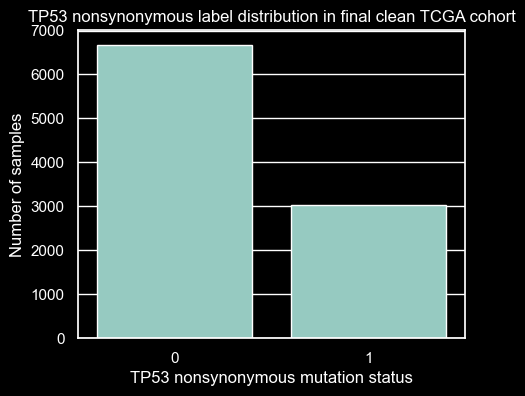

In [14]:
label_summary_clean = pd.Series({
    "n_samples": len(model_eda),
    "n_tp53_nonsyn": int(model_eda["TP53_mut_nonsyn"].sum()),
    "n_tp53_wildtype_or_no_nonsyn": int((model_eda["TP53_mut_nonsyn"] == 0).sum()),
    "tp53_nonsyn_rate": float(model_eda["TP53_mut_nonsyn"].mean()),
})

display(label_summary_clean.to_frame("value"))

plt.figure(figsize=(5, 4))
sns.countplot(data=model_eda, x="TP53_mut_nonsyn")
plt.title("TP53 nonsynonymous label distribution in final clean TCGA cohort")
plt.xlabel("TP53 nonsynonymous mutation status")
plt.ylabel("Number of samples")
plt.show()

## Cancer-type composition and TP53 prevalence

This section checks whether cancer type is likely to confound pan-cancer TP53 prediction.

,n_samples,tp53_rate,n_tp53
cancer type abbreviation,,,
BRCA,1090,0.239450,261
KIRC,530,0.020755,11
HNSC,518,0.677606,351
LUAD,513,0.500975,257
LGG,510,0.472549,241
THCA,504,0.005952,3
PRAD,495,0.117172,58
LUSC,495,0.795960,394
SKCM,464,0.146552,68


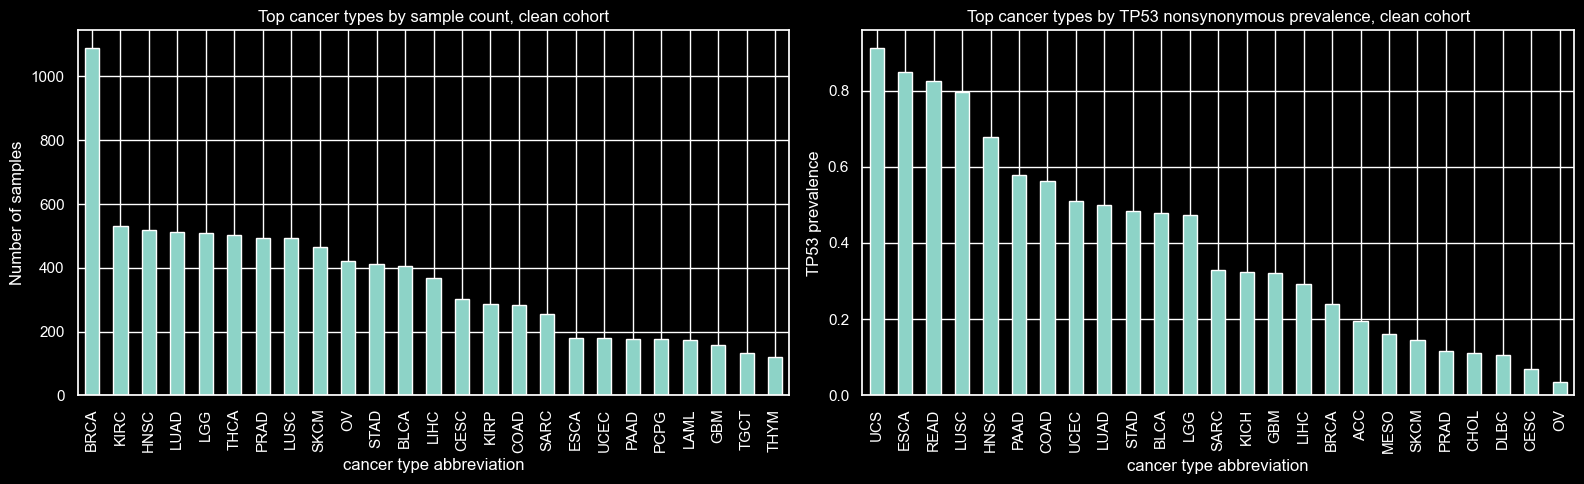

In [15]:
cancer_stats_clean = (
    model_eda
    .groupby(CANCER_TYPE_COL)
    .agg(
        n_samples=("sample_id", "size"),
        tp53_rate=("TP53_mut_nonsyn", "mean"),
        n_tp53=("TP53_mut_nonsyn", "sum"),
    )
    .sort_values("n_samples", ascending=False)
)

display(cancer_stats_clean)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cancer_stats_clean["n_samples"].sort_values(ascending=False).head(25).plot(
    kind="bar",
    ax=axes[0],
)
axes[0].set_title("Top cancer types by sample count, clean cohort")
axes[0].set_ylabel("Number of samples")

cancer_stats_clean["tp53_rate"].sort_values(ascending=False).head(25).plot(
    kind="bar",
    ax=axes[1],
)
axes[1].set_title("Top cancer types by TP53 nonsynonymous prevalence, clean cohort")
axes[1].set_ylabel("TP53 prevalence")

plt.tight_layout()
plt.show()

### Cancer-type interpretation

If TP53 prevalence differs strongly across cancer types, then random pan-cancer train/test splits may overestimate performance because train and test contain similar cancer-type mixtures. The modelling notebook should therefore include:

- a dummy prior baseline;
- a cancer-type-only baseline;
- an RNA-only model;
- an RNA + cancer-type model;
- cancer-type-grouped evaluation.

## Metadata missingness

In [16]:
metadata_cols_to_check = [
    "sample_id",
    "patient_id",
    "sample_type_code",
    "sample_type_label",
    "is_tumor_sample",
    CANCER_TYPE_COL,
    "TP53_mut_nonsyn",
    "TP53_mut_ambiguous",
    "has_mixed_tp53_annotation",
]

metadata_missing_raw = (
    merged[metadata_cols_to_check]
    .isna()
    .mean()
    .sort_values(ascending=False)
)

metadata_missing_clean = (
    model_eda[metadata_cols_to_check]
    .isna()
    .mean()
    .sort_values(ascending=False)
)

display(metadata_missing_raw.to_frame("missing_fraction_raw_merged"))
display(metadata_missing_clean.to_frame("missing_fraction_clean_cohort"))

,missing_fraction_raw_merged
sample_type_code,0.003702
sample_type_label,0.003702
is_tumor_sample,0.003702
cancer type abbreviation,0.003702
patient_id,0.003322
sample_id,0.000000
TP53_mut_nonsyn,0.000000
TP53_mut_ambiguous,0.000000
has_mixed_tp53_annotation,0.000000


,missing_fraction_clean_cohort
sample_id,0.0
patient_id,0.0
sample_type_code,0.0
sample_type_label,0.0
is_tumor_sample,0.0
cancer type abbreviation,0.0
TP53_mut_nonsyn,0.0
TP53_mut_ambiguous,0.0
has_mixed_tp53_annotation,0.0


## RNA expression structure in the final clean cohort

Expression matrix for clean cohort: (9695, 60498)
RNA feature count: 60498
Overall missing fraction: 0.0


,gene_variance
count,6.049800e+04
mean,4.722314e+00
std,5.744385e+00
min,3.155769e-30
25%,5.754346e-01
50%,2.300550e+00
75%,7.395137e+00
max,7.471875e+01


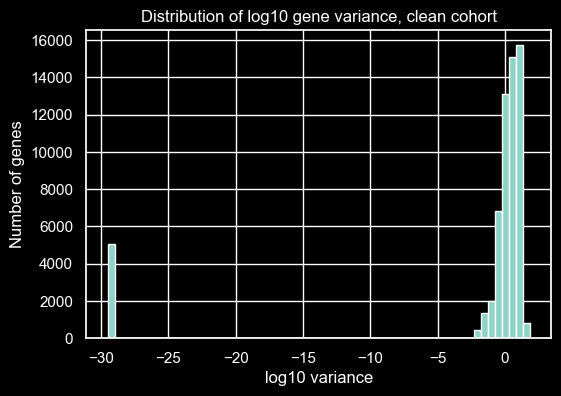

,n_genes
genes_with_variance_le_1e-06,5069
genes_with_variance_le_0.0001,5069
genes_with_variance_le_0.001,5069
genes_with_variance_le_0.01,5152


In [17]:
# Align expression matrix to the final clean cohort without duplicating expression columns in the metadata table.
model_sample_ids = model_eda["sample_id"].tolist()
expr_clean = rna_mat.reindex(model_sample_ids)
expr_clean.index = model_eda.index

assert expr_clean.shape[0] == len(model_eda)
assert expr_clean.isna().mean().mean() < 0.05, "Unexpectedly high expression missingness."

gene_cols = expr_clean.columns.tolist()
print("Expression matrix for clean cohort:", expr_clean.shape)
print("RNA feature count:", expr_clean.shape[1])
print("Overall missing fraction:", float(expr_clean.isna().mean().mean()))

gene_var = expr_clean.var(axis=0)
display(gene_var.describe().to_frame("gene_variance"))

plt.figure(figsize=(6, 4))
plt.hist(np.log10(gene_var.replace(0, np.nan).dropna()), bins=60)
plt.title("Distribution of log10 gene variance, clean cohort")
plt.xlabel("log10 variance")
plt.ylabel("Number of genes")
plt.show()

var_thresholds = [1e-6, 1e-4, 1e-3, 1e-2]
variance_filter_summary = pd.Series({
    f"genes_with_variance_le_{thr}": int((gene_var <= thr).sum())
    for thr in var_thresholds
})
display(variance_filter_summary.to_frame("n_genes"))

### RNA dimensionality conclusion

The RNA matrix is very high-dimensional relative to sample size. Dimensionality reduction, variance filtering, and supervised feature selection may be useful, but any supervised feature selection must be done inside training/CV folds in the modelling notebook.

## PCA on high-variance genes

This PCA is descriptive only. It should not be used for final model selection.

,PC1,PC2,PC3,PC4,PC5,TP53_mut_nonsyn,cancer type abbreviation
0,-23.974610,-12.993731,16.763394,1.464457,15.430758,0,GBM
1,-13.955581,-9.764000,8.333843,2.167282,7.339569,1,GBM
2,-27.915882,-13.068982,10.830295,-0.607605,7.360339,1,GBM
3,-27.821417,-10.905898,15.626859,-0.199058,10.497874,1,GBM
4,-0.123688,-4.954301,12.515860,-2.890930,-7.257321,0,OV


Explained variance ratio, first 5 PCs: [0.11453342 0.05620332 0.04338733 0.04042788 0.0339232 ]


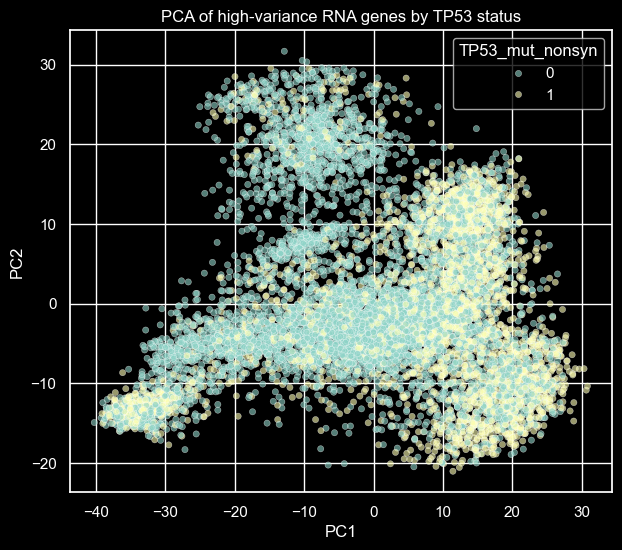

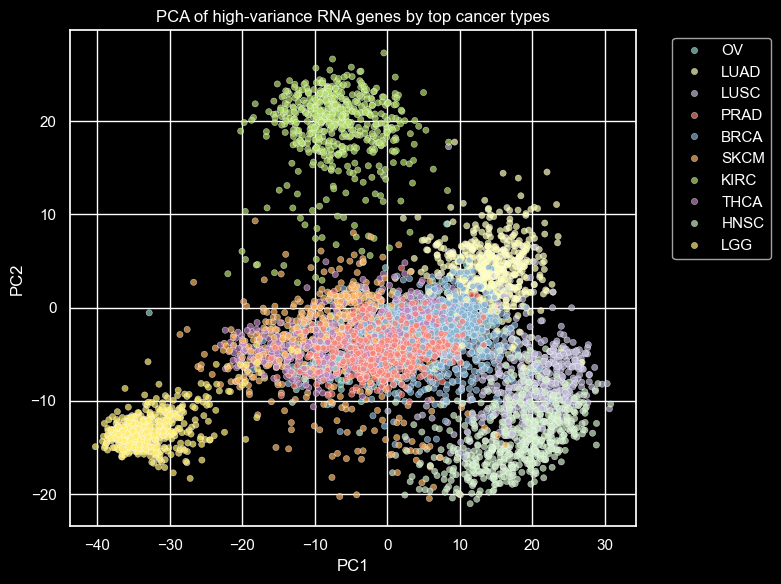

In [18]:
# Use top variable genes for stable PCA.
top_var_genes = gene_var.sort_values(ascending=False).head(TOP_VAR_GENES_FOR_PCA).index.tolist()

X_pca_input = expr_clean[top_var_genes].copy()
X_pca_input = X_pca_input.fillna(X_pca_input.median())

X_scaled = StandardScaler().fit_transform(X_pca_input)
pca = PCA(n_components=10, random_state=RANDOM_STATE)
pca_scores = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    pca_scores[:, :5],
    columns=[f"PC{i}" for i in range(1, 6)],
    index=model_eda.index,
)
pca_df["TP53_mut_nonsyn"] = model_eda["TP53_mut_nonsyn"].values
pca_df[CANCER_TYPE_COL] = model_eda[CANCER_TYPE_COL].values

display(pca_df.head())
print("Explained variance ratio, first 5 PCs:", pca.explained_variance_ratio_[:5])

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="TP53_mut_nonsyn",
    alpha=0.6,
    s=20,
)
plt.title("PCA of high-variance RNA genes by TP53 status")
plt.show()

top_types = cancer_stats_clean.head(10).index
pca_top = pca_df.loc[pca_df[CANCER_TYPE_COL].isin(top_types)].copy()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_top,
    x="PC1",
    y="PC2",
    hue=CANCER_TYPE_COL,
    alpha=0.7,
    s=20,
)
plt.title("PCA of high-variance RNA genes by top cancer types")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### PCA interpretation

PCA is expected to reflect broad cancer-type structure more strongly than TP53 mutation status. This supports the modelling plan to include a cancer-type-only baseline and cancer-type-grouped evaluation. Random pan-cancer splits are likely easier than generalizing to held-out cancer types.

## TP53 target-gene and gene-identifier limitation

The RNA matrix typically uses Ensembl gene IDs, while TP53 target-gene lists often use gene symbols. Direct overlap between Ensembl IDs and symbols is not meaningful without an annotation map.

In [19]:
print("Example RNA feature IDs:")
display(pd.Series(gene_cols[:10], name="rna_feature_id"))

if TP53_TARGETS_PATH is not None and Path(TP53_TARGETS_PATH).exists():
    tp53_targets = pd.read_csv(TP53_TARGETS_PATH)
    print("TP53 target list shape:", tp53_targets.shape)
    display(tp53_targets.head())
else:
    tp53_targets = None
    print("No TP53 target-gene list found.")

if GENE_ANNOTATION_PATH is not None:
    print("Gene annotation file found:", GENE_ANNOTATION_PATH)
else:
    print("No gene annotation file found. Biological interpretation will be limited to Ensembl IDs.")

print("Direct symbol-to-Ensembl overlap should not be interpreted without annotation.")

Example RNA feature IDs:


0     ENSG00000242268.2
1     ENSG00000259041.1
2     ENSG00000270112.3
3    ENSG00000167578.16
4     ENSG00000278814.1
5     ENSG00000078237.5
6     ENSG00000269416.5
7     ENSG00000263642.1
8    ENSG00000146083.11
9    ENSG00000158486.13
Name: rna_feature_id, dtype: str

TP53 target list shape: (343, 1)


,gene_symbol
0,ABCA12
1,ABHD4
2,ABTB2
3,ACER2
4,ACTA2


No gene annotation file found. Biological interpretation will be limited to Ensembl IDs.
Direct symbol-to-Ensembl overlap should not be interpreted without annotation.


## Exploratory RNA-label differences

This section is descriptive only. It should not be used as final feature selection because it uses the full clean cohort and labels.

In [20]:
y_clean = model_eda["TP53_mut_nonsyn"].astype(int).values

group0 = expr_clean.loc[y_clean == 0]
group1 = expr_clean.loc[y_clean == 1]

effect_size = group1.mean(axis=0) - group0.mean(axis=0)
effect_df = effect_size.sort_values(ascending=False).rename("mean_diff_mut_minus_wt").to_frame()

display(effect_df.head(20))
display(effect_df.tail(20))

,mean_diff_mut_minus_wt
sample,
ENSG00000169469.8,4.562190
ENSG00000241794.1,4.439168
ENSG00000105388.14,4.316913
ENSG00000169474.4,4.215463
ENSG00000163216.6,4.207809
ENSG00000205420.10,4.201391
ENSG00000185479.5,4.079017
ENSG00000206075.13,3.850243
ENSG00000249395.2,3.803049


,mean_diff_mut_minus_wt
sample,
ENSG00000234779.1,-1.781997
ENSG00000105707.13,-1.790545
ENSG00000227568.1,-1.791834
ENSG00000279208.1,-1.793079
ENSG00000196415.9,-1.811815
ENSG00000249494.5,-1.835939
ENSG00000238243.3,-1.844602
ENSG00000160678.11,-1.850452
ENSG00000151365.2,-1.892142


### Warning

The exploratory RNA-label differences above are useful for sanity checking, but they are not a leakage-safe feature-selection procedure. In the modelling notebook, supervised feature selection must be performed only within training/CV folds.

# EDA conclusions

## Proposed main label

The primary target should be `TP53_mut_nonsyn`, defined as whether a sample has at least one nonsynonymous / protein-altering TP53 mutation.

This is preferable to using any TP53 mutation row because it avoids treating synonymous or ambiguous TP53 annotations as equivalent to protein-altering mutations.

## Final modelling cohort

The final TCGA modelling cohort should use the following rules:

1. Keep samples present in the RNA matrix.
2. Keep tumour samples only, based on TCGA sample-type barcode codes.
3. Exclude samples with missing cancer type.
4. Exclude samples with ambiguous or mixed TP53 mutation annotation.
5. Keep one sample per patient to avoid patient-level leakage.
6. Prefer primary tumour samples when multiple tumour samples exist for the same patient.

In the current TCGA/Xena data used by the modelling notebook, this should produce approximately:

- 9,695 samples
- 9,695 unique patients
- 33 cancer types
- 3,021 TP53 nonsynonymous positives
- 6,674 TP53 negatives
- TP53 prevalence around 31.2%

If these values differ substantially after running this notebook, check whether the input files or barcode normalization differ from the modelling notebook.

## Main EDA findings

TP53 mutation status is moderately imbalanced. Accuracy alone is therefore not sufficient; AUPRC, AUROC, balanced accuracy, F1, and confusion matrices should be reported.

Cancer type is a major confounder. Some cancer types have very high TP53 mutation prevalence, while others have very low or zero prevalence. Because cancer type also strongly affects RNA expression, random pan-cancer train/test splits may overestimate generalization.

The RNA matrix is high-dimensional, with roughly 60,000 expression features. Dimensionality reduction, variance filtering, and supervised feature selection must be handled carefully.

The RNA matrix appears to use Ensembl gene IDs, while the TP53 target list uses gene symbols. Direct biological interpretation requires an Ensembl-to-symbol annotation map.

## Main modelling risks

1. Patient-level leakage if multiple samples from the same patient appear across train/test splits.
2. Cancer-type confounding in pan-cancer prediction.
3. Supervised feature-selection leakage if RNA features are selected before splitting.
4. Misleading biological interpretation if Ensembl IDs are not mapped to gene symbols.
5. Overclaiming random-split performance as evidence of general biological TP53 prediction.

## Modelling notebook plan

The modelling notebook should use:

1. dummy prior baseline;
2. cancer-type-only baseline;
3. RNA-only regularized model;
4. RNA + cancer-type model;
5. random stratified holdout evaluation;
6. cancer-type-grouped evaluation;
7. all RNA preprocessing and supervised feature selection inside training/CV folds;
8. cautious interpretation of coefficients unless gene-symbol annotation is available.